In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)

from src.utils import configure_logger

import pandas as pd

from typing import Any 
from GNN.training.utils import collect_dataset_paths
from GNN.training.runners import MODEL_REGISTRY
from GNN.training.train_config import TrainConfig

from collections.abc import Callable
Loader = Callable[..., Any]

In [4]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from experiments.plotting import _plot_SRE_distribution
from GNN.dataset_builder import (
    DataGenConfig,
    RegimeDistribution,
    SamplingConfig,
    run_dataset_pipeline,
)
PROJECT_ROOT = Path().resolve().parent

In [6]:
n_qubits = (4, 6, 8, 10)
n_layers = (1, 2, 4, 8, 16, 40, 50, 80, 100)
n_seeds = 50
output_dir = "temp/datasets/SRE_distribution"

In [7]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd


def load_sre_dataset(root: str | Path) -> pd.DataFrame:
    root = Path(root)
    rows = []

    for path in root.rglob("*.pt"):
        try:
            payload = torch.load(path, map_location="cpu", weights_only=False)
        except Exception as exc:
            print(f"Could not load {path}: {exc}")
            continue

        meta = payload.get("meta", {})

        if "sre" not in payload:
            continue

        sre = float(payload["sre"])

        if not np.isfinite(sre):
            continue

        n_qubits = int(meta.get("n_qubits", -1))
        n_layers = int(meta.get("n_layers", -1))
        family = meta.get("family", "unknown")

        row = {
            "path": str(path),
            "family": family,
            "n_qubits": n_qubits,
            "n_layers": n_layers,
            "seed": int(meta.get("seed", -1)),
            "sre": sre,
            "sre_density": sre / n_qubits if n_qubits > 0 else np.nan,
            "regime": meta.get("regime", "unknown"),
        }

        controls = meta.get("sampling_controls", {})
        for k, v in controls.items():
            row[f"ctrl_{k}"] = v

        gate_counts = payload.get("gate_counts", {})
        for k, v in gate_counts.items():
            if isinstance(v, (int, float)):
                row[f"count_{k}"] = v

        rows.append(row)

    return pd.DataFrame(rows)

In [8]:
import matplotlib.pyplot as plt
import numpy as np


def plot_global_sre_distribution(df: pd.DataFrame, family: str, density: bool = True):
    sub = df[df["family"] == family].copy()

    col = "sre_density" if density else "sre"
    xlabel = "SRE / n_qubits" if density else "SRE"

    values = sub[col].dropna().to_numpy()

    plt.figure(figsize=(7, 4))
    plt.hist(values, bins=40, alpha=0.8)
    plt.xlabel(xlabel)
    plt.ylabel("Number of circuits")
    plt.title(f"{family}: global {xlabel} distribution")
    plt.tight_layout()
    plt.show()

def plot_sre_ecdf(df: pd.DataFrame, family: str, density: bool = True):
    sub = df[df["family"] == family].copy()

    col = "sre_density" if density else "sre"
    xlabel = "SRE / n_qubits" if density else "SRE"

    values = np.sort(sub[col].dropna().to_numpy())

    if len(values) == 0:
        print(f"No values for {family}")
        return

    y = np.arange(1, len(values) + 1) / len(values)

    plt.figure(figsize=(7, 4))
    plt.plot(values, y)
    plt.xlabel(xlabel)
    plt.ylabel("Cumulative fraction")
    plt.title(f"{family}: empirical CDF of {xlabel}")
    plt.tight_layout()
    plt.show()

def add_sre_bins(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    bins = [-1e-12, 1e-5, 0.05, 0.10, 0.20, 0.35, 0.50, 0.75, np.inf]
    labels = [
        "zero",
        "tiny",
        "very_low",
        "low",
        "medium_low",
        "medium",
        "high",
        "very_high",
    ]

    df["sre_bin"] = pd.cut(
        df["sre_density"],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )

    return df

def plot_sre_vs_layers(df: pd.DataFrame, family: str):
    sub = df[df["family"] == family].copy()

    plt.figure(figsize=(7, 4))
    plt.scatter(
        sub["n_layers"],
        sub["sre_density"],
        s=12,
        alpha=0.35,
    )
    plt.xlabel("Number of layers")
    plt.ylabel("SRE / n_qubits")
    plt.title(f"{family}: SRE density vs depth")
    plt.tight_layout()
    plt.show()

def plot_sre_by_qubits(df: pd.DataFrame, family: str):
    sub = df[df["family"] == family].copy()

    plt.figure(figsize=(7, 4))
    sub.boxplot(column="sre_density", by="n_qubits")
    plt.suptitle("")
    plt.title(f"{family}: SRE density by number of qubits")
    plt.xlabel("n_qubits")
    plt.ylabel("SRE / n_qubits")
    plt.tight_layout()
    plt.show()

In [9]:
def make_dataset_loaders(
    model_type: str,
    epochs: int,
    lr: float,
    loss_type: str,
    batch_size: int,
    training_mode: str,
    family: str,
    target: str,
    data_dir: str,
    model_save_path: str,
    show_progress: bool = True,
    show_val_progress: bool = False,
    log_every_n_batches: int = 10,
    heartbeat_secs: float = 60.0,
    epoch_time_warning_secs: float = 600.0,
):
    cfg = TrainConfig(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        show_progress=show_progress,
        show_val_progress=show_val_progress,
        log_batch_loss_every=log_every_n_batches,
        heartbeat=heartbeat_secs,
        epoch_warning=epoch_time_warning_secs,
    )

    train_paths = collect_dataset_paths(
        data_dir,
        family=family if training_mode == "per_family" else None,
        split="target",
    )
    if not train_paths:
        raise RuntimeError("No data paths found.")
    logger.info(f"Found {len(train_paths)} data paths.")
    logger.info("Data paths collected.")

    spec = MODEL_REGISTRY[model_type]
    logger.info(f"Building loaders and model for model_type={model_type}...")

    loader_fn: Loader = spec["build_loaders"]
    returns_nodes_dim: bool = spec.get("returns_nodes_dim", False)
    if returns_nodes_dim:
        train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset = loader_fn(
            train_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family,
        )
    else:
        train_loader, val_loader, test_loader, global_in_dim, base_dataset = loader_fn(
            train_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family,
        )
        node_in_dim = global_in_dim

    return train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset

In [10]:
def plot_SRE_regime(output_dir: str, family: str):
    rows = []

    for path in Path(output_dir+"/"+family).rglob("*.pt"):
        d = torch.load(path, map_location="cpu")

        meta = d["meta"]
        controls = meta.get("sampling_controls", {})
        realized = meta.get("realized_stats", {})

        row = {
            "path": str(path),
            "family": meta["family"],
            "regime": meta["regime"],
            "n_qubits": meta["n_qubits"],
            "n_layers": meta["n_layers"],
            "seed": meta["seed"],
            "sre": float(d.get("sre", np.nan)),
            "sre_density": float(d.get("sre", np.nan)) / meta["n_qubits"],
        }

        row.update({f"ctrl_{k}": v for k, v in controls.items()})
        row.update({f"real_{k}": v for k, v in realized.items()})

        rows.append(row)

    df = pd.DataFrame(rows)

    for family in df["family"].unique():
        sub = df[(df["family"] == family) & np.isfinite(df["sre_density"])]

        plt.figure()
        sub.boxplot(column="sre_density", by="regime", rot=45)
        plt.title(f"{family}: SRE density by regime")
        plt.suptitle("")
        plt.ylabel("SRE / n_qubits")
        plt.tight_layout()
        plt.show()

## Random rotations

In [120]:
print(0.005+ 0.155+ 0.3+ 0.25+ 0.15 + 0.14)

1.0


In [121]:
def default_sampling_config() -> SamplingConfig:
    return SamplingConfig(
        random=RegimeDistribution(
            regimes=[
                "identity_like",
                "near_clifford",
                "small_angles",
                "medium_angles",
                "generic_sparse",
                "generic_dense",
            ],
            probabilities=[0.005, 0.155, 0.3, 0.25, 0.15, 0.14],
        ),
    )

In [122]:
n_qubits = (4, 6, 8, 10)
n_layers = (1, 2, 4, 8, 16, 40, 50, 80, 100)
n_seeds = 50
output_dir = "temp/datasets/SRE_distribution_8"

In [123]:
rand_config = DataGenConfig(
    backend="pennylane",
    method="fwht",
    families=["random"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    prediction_n_seeds = None,
    n_bins=50,
    compute_sre=True,
    compute_EE=False,
    target_qubits=(4,6,8),
    representation="dense",
    use_dask=True,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    output_dir=Path(output_dir),
    max_configs=None,
)

run_dataset_pipeline(
    config=rand_config,
    families=["random"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=rand_config.n_seeds,
    use_dask=True,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    sampling_config=default_sampling_config(),
)

2026-05-25 13:33:46,374 - GNN.dataset_builder - INFO - Processing family: random
2026-05-25 13:33:46,379 - GNN.dataset_builder - INFO - Generated 1800 configs for random
2026-05-25 13:33:46,379 - parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-05-25 13:33:46,402 - distributed.scheduler - INFO - State start
2026-05-25 13:33:46,423 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:65503
2026-05-25 13:33:46,423 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-05-25 13:33:46,423 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-05-25 13:33:46,493 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:65508'
2026-05-25 13:33:46,495 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:65506'
2026-05-25 13:33:46,497 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:65512'
2026-05-25 13:33:46,499 - distributed.nanny - INFO

In [124]:
# output_dir = "../outputs/data/temp_dataset"

In [125]:
print(f"Loading dataset from {output_dir}...")
df = load_sre_dataset(output_dir)

print(df.shape)
print(df[["family", "n_qubits", "n_layers", "sre", "sre_density"]].head())

Loading dataset from temp/datasets/SRE_distribution_8...
(1350, 168)
   family  n_qubits  n_layers       sre  sre_density
0  random         4       100  2.158633     0.539658
1  random         4       100  0.012974     0.003244
2  random         4       100  0.326704     0.081676
3  random         4       100  1.992051     0.498013
4  random         4       100  1.264117     0.316029


In [126]:
# df_qubits = df[df["n_qubits"] == 8].copy()
df_qubits = df.copy()

In [127]:
model_type = "nn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "clifford"  # required if training_mode == "per_family"
target = "sre"
data_dir = output_dir
model_save_path = "../outputs/models/clifford_model_gnn.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0

In [ ]:
train_loader_random, val_loader_random, test_loader_random, node_in_dim_random, global_in_dim_random, base_dataset_random = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "random", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)

2026-05-25 13:35:53,001 - __main__ - INFO - Found 1350 data paths.
2026-05-25 13:35:53,002 - __main__ - INFO - Data paths collected.
2026-05-25 13:35:53,002 - __main__ - INFO - Building loaders and model for model_type=nn...


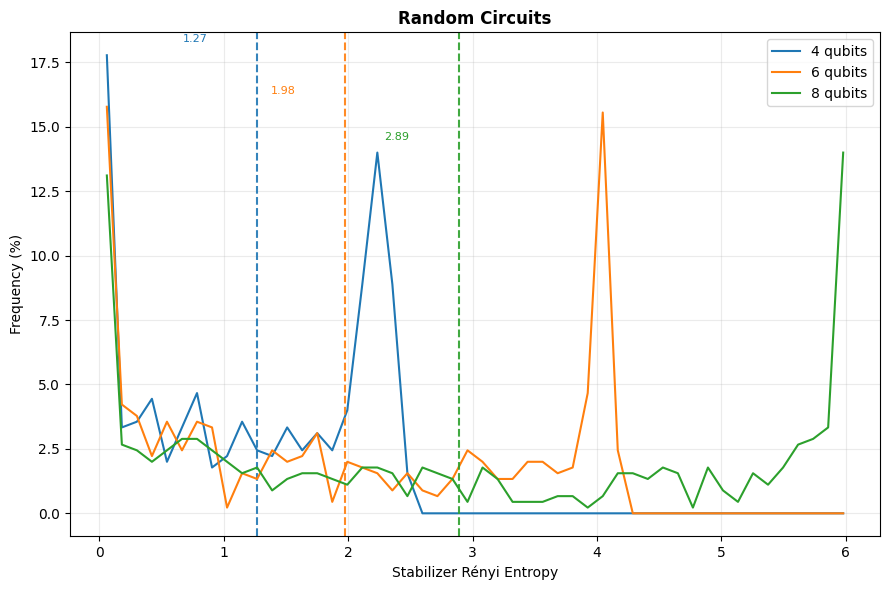

In [129]:
_plot_SRE_distribution(base_dataset_random, bins=50, title="Random Circuits")

<Figure size 640x480 with 0 Axes>

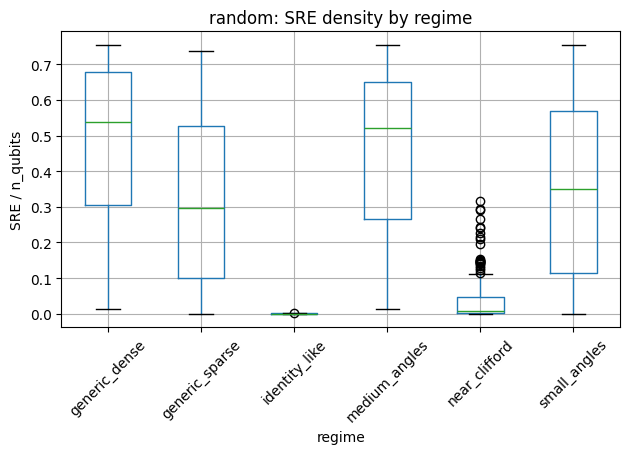

In [ ]:
plot_SRE_regime(output_dir, "random")

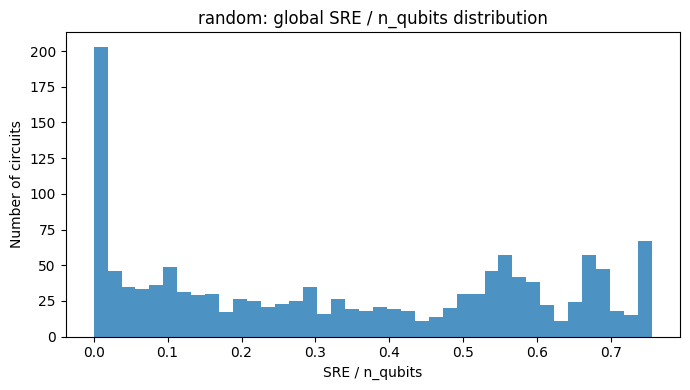

In [ ]:
plot_global_sre_distribution(df_qubits, "random", density=True)

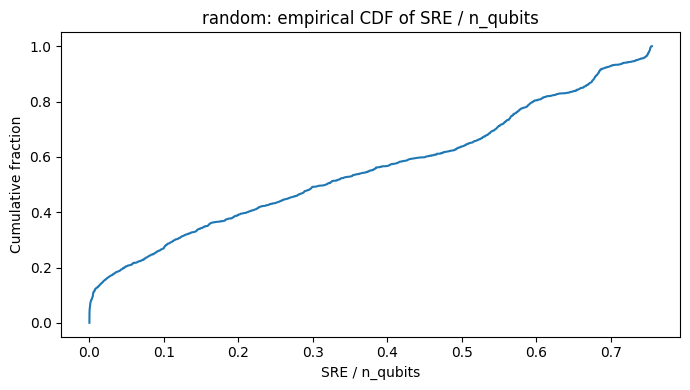

In [ ]:
plot_sre_ecdf(df_qubits, "random", density=True)

In [133]:
df_qubits = add_sre_bins(df_qubits)

coverage_table = pd.crosstab(
    df_qubits["family"],
    df_qubits["sre_bin"],
    normalize="index",
)

print(coverage_table)

sre_bin      zero      tiny  very_low       low  medium_low    medium  \
family                                                                  
random   0.026667  0.177778  0.065185  0.121481    0.137037  0.108889   

sre_bin      high  very_high  
family                        
random   0.337778   0.025185  


## Clifford

In [279]:
0.05+ 0.05+ 0.1+ 0.1+ 0.2+ 0.20+ 0.20+ 0.1

0.9999999999999999

In [280]:
n_qubits = (4, 6, 8, 10)
n_layers = (1, 2, 4, 8, 16, 40, 50, 80, 100)
n_seeds = 50
output_dir = "temp/datasets/SRE_distribution_12"

In [281]:
def default_sampling_config() -> SamplingConfig:
    return SamplingConfig(
        clifford=RegimeDistribution(
            regimes=[
                "zero",
                "tiny",
                "very_low",
                "low",
                "medium_low",
                "medium",
                "medium_high",
                "high",
            ],
            probabilities=[
                0.05,
                0.05,
                0.10,
                0.10,
                0.20,
                0.20,
                0.20,
                0.10,
            ],
        ),
    )

In [282]:
cliff_config = DataGenConfig(
    backend="pennylane",
    method="fwht",
    families=["clifford"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    prediction_n_seeds = None,
    n_bins=50,
    compute_sre=True,
    compute_EE=False,
    target_qubits=(4,6,8),
    representation="dense",
    use_dask=True,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    output_dir=Path(output_dir),
    max_configs=None,
)

run_dataset_pipeline(
    config=cliff_config,
    families=["clifford"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=cliff_config.n_seeds,
    use_dask=True,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    sampling_config=default_sampling_config(),
)

2026-05-25 16:43:42,447 - GNN.dataset_builder - INFO - Processing family: clifford
2026-05-25 16:43:42,451 - GNN.dataset_builder - INFO - Generated 1800 configs for clifford
2026-05-25 16:43:42,453 - parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-05-25 16:43:42,473 - distributed.scheduler - INFO - State start
2026-05-25 16:43:42,495 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:59464
2026-05-25 16:43:42,495 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-05-25 16:43:42,496 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-05-25 16:43:42,559 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:59471'
2026-05-25 16:43:42,562 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:59467'
2026-05-25 16:43:42,565 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:59469'
2026-05-25 16:43:42,567 - distributed.nanny - 

In [283]:
# output_dir = "../outputs/data/temp_dataset"

In [284]:
model_type = "nn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "clifford"  # required if training_mode == "per_family"
target = "sre"
data_dir = output_dir
model_save_path = "../outputs/models/clifford_model_gnn.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
train_loader_clifford, val_loader_clifford, test_loader_clifford, node_in_dim_clifford, global_in_dim_clifford, base_dataset_clifford = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "clifford", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)

2026-05-25 16:45:54,958 - __main__ - INFO - Found 1350 data paths.
2026-05-25 16:45:54,958 - __main__ - INFO - Data paths collected.
2026-05-25 16:45:54,959 - __main__ - INFO - Building loaders and model for model_type=nn...


In [285]:
print(f"Loading dataset from {output_dir}...")
df = load_sre_dataset(output_dir)

print(df.shape)
print(df[["family", "n_qubits", "n_layers", "sre", "sre_density"]].head())

Loading dataset from temp/datasets/SRE_distribution_12...
(1350, 22)
     family  n_qubits  n_layers           sre   sre_density
0  clifford         4       100  7.431949e-14  1.857987e-14
1  clifford         4       100  4.150375e-01  1.037594e-01
2  clifford         4       100  1.904994e+00  4.762485e-01
3  clifford         4       100  9.097731e-14  2.274433e-14
4  clifford         4       100  2.105751e+00  5.264378e-01


In [286]:
# df_qubits = df[df["n_qubits"] == 8].copy()
df_qubits = df.copy()

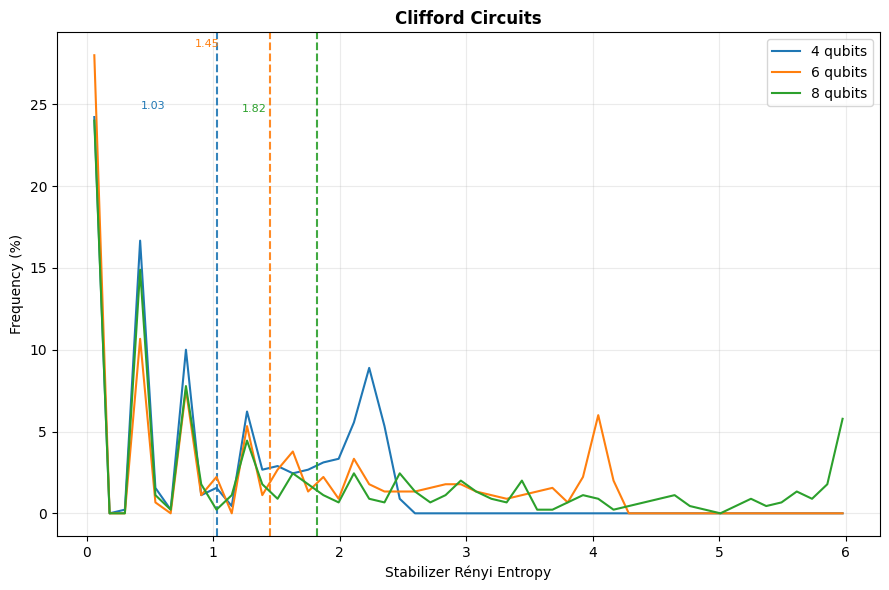

<Figure size 640x480 with 0 Axes>

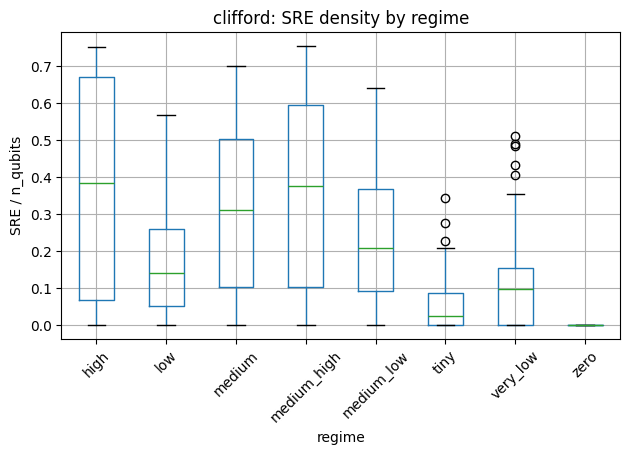

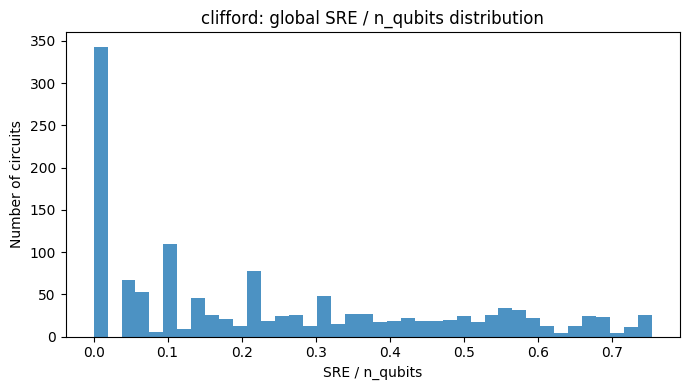

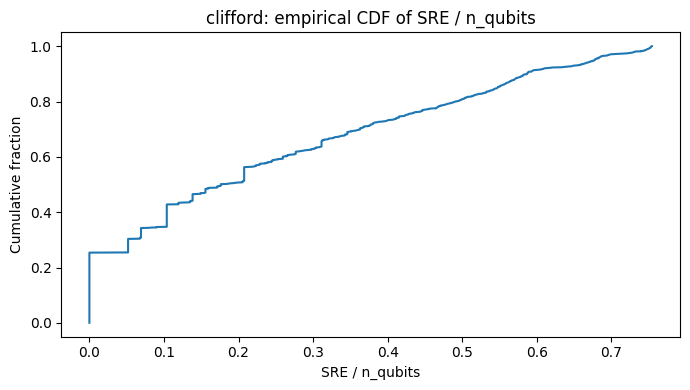

In [292]:
_plot_SRE_distribution(base_dataset_clifford, bins=50, title="Clifford Circuits")
plot_SRE_regime(output_dir, "clifford")

plot_global_sre_distribution(df_qubits, "clifford", density=True)
plot_sre_ecdf(df_qubits, "clifford", density=True)

In [288]:
df_qubits = add_sre_bins(df_qubits)

coverage_table = pd.crosstab(
    df_qubits["family"],
    df_qubits["sre_bin"],
    normalize="index",
)

print(coverage_table)

sre_bin       zero  very_low       low  medium_low    medium      high  \
family                                                                   
clifford  0.254074  0.092593  0.160741    0.183704  0.117037  0.182222   

sre_bin   very_high  
family               
clifford    0.00963  


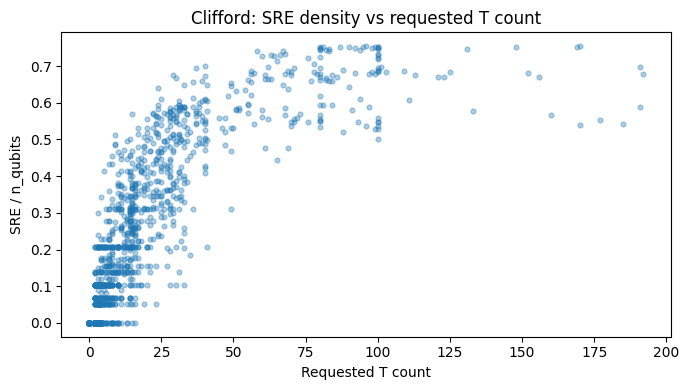

In [289]:
plt.figure(figsize=(7, 4))
plt.scatter(
    df_qubits["ctrl_t_count"],
    df_qubits["sre_density"],
    s=12,
    alpha=0.35,
)
plt.xlabel("Requested T count")
plt.ylabel("SRE / n_qubits")
plt.title("Clifford: SRE density vs requested T count")
plt.tight_layout()
plt.show()

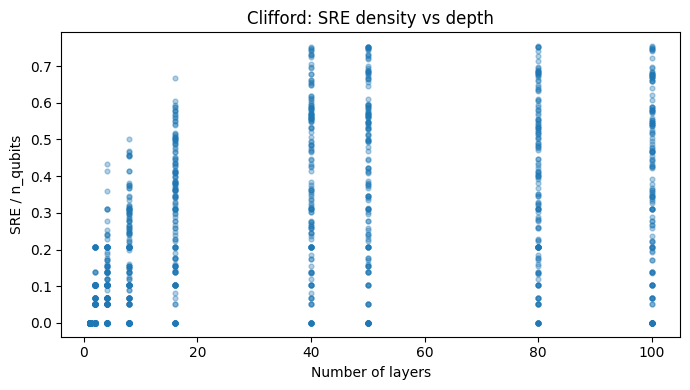

In [290]:
plt.figure(figsize=(7, 4))
plt.scatter(
    df_qubits["n_layers"],
    df_qubits["sre_density"],
    s=12,
    alpha=0.35,
)
plt.xlabel("Number of layers")
plt.ylabel("SRE / n_qubits")
plt.title("Clifford: SRE density vs depth")
plt.tight_layout()
plt.show()

In [291]:
df_qubits["t_bin"] = pd.cut(
    df_qubits["ctrl_t_count"],
    bins=[-0.5, 0.5, 1.5, 3.5, 7.5, 15.5, 31.5, np.inf],
    labels=[
        "0",
        "1",
        "2-3",
        "4-7",
        "8-15",
        "16-31",
        "32+",
    ],
)

pd.crosstab(
    df_qubits["t_bin"],
    df_qubits["sre_bin"],
    normalize="index",
)

sre_bin,zero,very_low,low,medium_low,medium,high,very_high
t_bin,,,,,,,
0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2-3,0.653979,0.162630,0.138408,0.044983,0.000000,0.000000,0.000000
4-7,0.285088,0.210526,0.359649,0.131579,0.013158,0.000000,0.000000
8-15,0.060150,0.097744,0.270677,0.428571,0.131579,0.011278,0.000000
16-31,0.003846,0.015385,0.080769,0.311538,0.357692,0.230769,0.000000
32+,0.000000,0.000000,0.008511,0.042553,0.114894,0.778723,0.055319


## Quansistor

In [293]:
def default_sampling_config() -> SamplingConfig:
    return SamplingConfig(
        quansistor=RegimeDistribution(
            regimes=[
                "identity_like",
                "weak",
                "moderate",
                "structured_equal_ab",
                "structured_opposite_ab",
                "generic_uniform",
            ],
            probabilities=[0.1, 0.4, 0.4, 0.1, 0.1, 0.1],
        ),
    )

In [295]:
n_qubits = (4, 6, 8, 10)
n_layers = (1, 2, 4, 8, 16, 40, 50, 80, 100)
n_seeds = 50
output_dir = "temp/datasets/SRE_distribution"

In [296]:
quan_config = DataGenConfig(
    backend="pennylane",
    method="fwht",
    families=["quansistor"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    prediction_n_seeds = None,
    n_bins=50,
    compute_sre=True,
    compute_EE=False,
    target_qubits=(4,6,8),
    representation="dense",
    use_dask=True,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    output_dir=Path(output_dir),
    max_configs=None,
)

run_dataset_pipeline(
    config=quan_config,
    families=["quansistor"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=quan_config.n_seeds,
    use_dask=True,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    sampling_config=default_sampling_config(),
)

2026-05-25 16:50:38,829 - GNN.dataset_builder - INFO - Processing family: quansistor
2026-05-25 16:50:38,835 - GNN.dataset_builder - INFO - Generated 1800 configs for quansistor
2026-05-25 16:50:38,836 - parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\qqe\.venv\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 55878 instead
  warnings.warn(
2026-05-25 16:50:38,866 - distributed.scheduler - INFO - State start
2026-05-25 16:50:39,141 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:55881
2026-05-25 16:50:39,141 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:55878/status
2026-05-25 16:50:39,142 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-05-25 16:50:39,218 - distributed.nanny - INFO -         Start Nanny at

In [297]:
model_type = "nn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "quansistor"  # required if training_mode == "per_family"
target = "sre"
data_dir = output_dir
model_save_path = "../outputs/models/quansistor_model_gnn.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
train_loader_quansistor, val_loader_quansistor, test_loader_quansistor, node_in_dim_quansistor, global_in_dim_quansistor, base_dataset_quansistor = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "quansistor", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)

2026-05-25 16:53:13,577 - __main__ - INFO - Found 1350 data paths.
2026-05-25 16:53:13,578 - __main__ - INFO - Data paths collected.
2026-05-25 16:53:13,578 - __main__ - INFO - Building loaders and model for model_type=nn...


In [298]:
print(f"Loading dataset from {output_dir}...")
df = load_sre_dataset(output_dir)

print(df.shape)
print(df[["family", "n_qubits", "n_layers", "sre", "sre_density"]].head())

Loading dataset from temp/datasets/SRE_distribution...
(4050, 472)
     family  n_qubits  n_layers           sre   sre_density
0  clifford         4       100  7.431949e-14  1.857987e-14
1  clifford         4       100  9.161800e-14  2.290450e-14
2  clifford         4       100  1.724145e+00  4.310362e-01
3  clifford         4       100  9.225868e-14  2.306467e-14
4  clifford         4       100  1.025096e-13  2.562741e-14


In [299]:
# df_qubits = df[df["n_qubits"] == 8].copy()
df_qubits = df.copy()

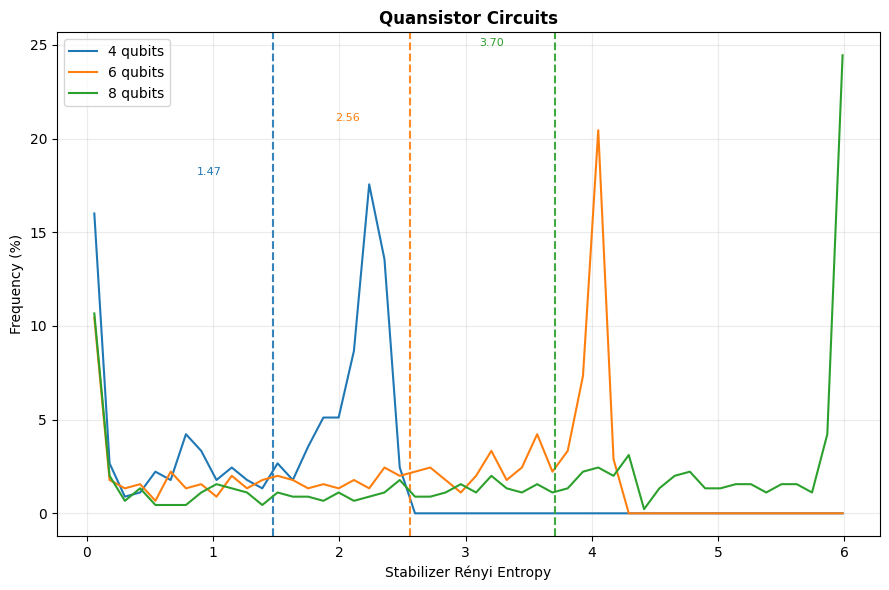

<Figure size 640x480 with 0 Axes>

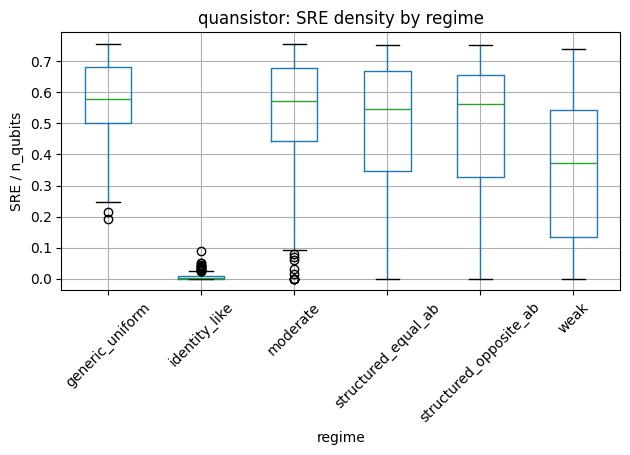

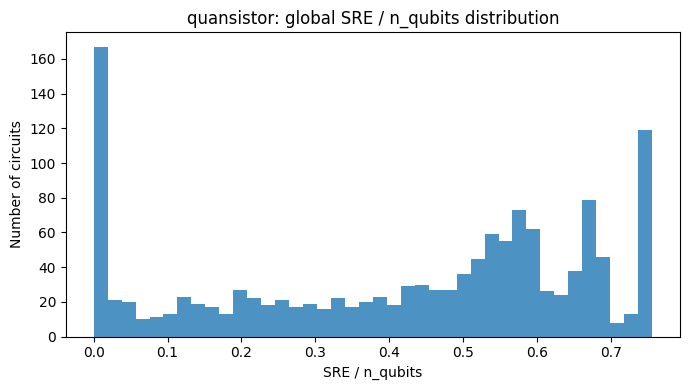

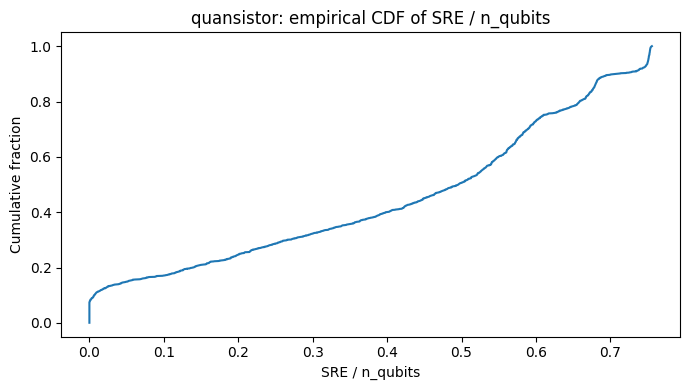

In [300]:
_plot_SRE_distribution(base_dataset_quansistor, bins=50, title="Quansistor Circuits")
plot_SRE_regime(output_dir, "quansistor")

plot_global_sre_distribution(df_qubits, "quansistor", density=True)
plot_sre_ecdf(df_qubits, "quansistor", density=True)

In [301]:
df_qubits = add_sre_bins(df_qubits)

coverage_table = pd.crosstab(
    df_qubits["family"],
    df_qubits["sre_bin"],
    normalize="index",
)

print(coverage_table)

sre_bin         zero      tiny  very_low       low  medium_low    medium  \
family                                                                     
clifford    0.422222  0.000000  0.180741  0.201481    0.100000  0.032593   
quansistor  0.074815  0.074074  0.022222  0.075556    0.110370  0.148889   
random      0.083704  0.457037  0.069630  0.073333    0.074074  0.081481   

sre_bin         high  very_high  
family                           
clifford    0.061481   0.001481  
quansistor  0.434074   0.060000  
random      0.151852   0.008889  


## Haar

In [29]:
def default_sampling_config() -> SamplingConfig:
    return SamplingConfig(
        haar=RegimeDistribution(
            regimes=[
                "none",
                "sparse_weak",
                "dense_weak",
                "sparse_full",
                "medium",
                "full",
            ],
            probabilities=[0.1, 0.2, 0.2, 0.1, 0.1, 0.3],
        ),
    )

In [30]:
n_qubits = (4, 6, 8, 10)
n_layers = (1, 2, 4, 8, 16, 40, 50, 80, 100)
n_seeds = 50
output_dir = "temp/datasets/SRE_distribution_3"

In [31]:
haar_config = DataGenConfig(
    backend="pennylane",
    method="fwht",
    families=["haar"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    prediction_n_seeds = None,
    n_bins=50,
    compute_sre=True,
    compute_EE=False,
    target_qubits=(4,6,8),
    representation="dense",
    use_dask=True,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    output_dir=Path(output_dir),
    max_configs=None,
)

run_dataset_pipeline(
    config=haar_config,
    families=["haar"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=haar_config.n_seeds,
    use_dask=True,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    sampling_config=default_sampling_config(),
)

2026-05-26 08:58:37,545 - GNN.dataset_builder - INFO - Processing family: haar
2026-05-26 08:58:37,549 - GNN.dataset_builder - INFO - Generated 1800 configs for haar
2026-05-26 08:58:37,551 - parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-05-26 08:58:37,571 - distributed.scheduler - INFO - State start
2026-05-26 08:58:37,590 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:54257
2026-05-26 08:58:37,590 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-05-26 08:58:37,590 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-05-26 08:58:37,652 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:54262'
2026-05-26 08:58:37,654 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:54260'
2026-05-26 08:58:37,657 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:54266'
2026-05-26 08:58:37,658 - distributed.nanny - INFO -  

In [32]:
model_type = "nn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "haar"  # required if training_mode == "per_family"
target = "sre"
data_dir = output_dir
model_save_path = "../outputs/models/haar_model_gnn.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
train_loader_haar, val_loader_haar, test_loader_haar, node_in_dim_haar, global_in_dim_haar, base_dataset_haar = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "haar", target, data_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)

2026-05-26 09:00:40,752 - __main__ - INFO - Found 1350 data paths.
2026-05-26 09:00:40,752 - __main__ - INFO - Data paths collected.
2026-05-26 09:00:40,752 - __main__ - INFO - Building loaders and model for model_type=nn...


In [33]:
print(f"Loading dataset from {output_dir}...")
df = load_sre_dataset(output_dir)

print(df.shape)
print(df[["family", "n_qubits", "n_layers", "sre", "sre_density"]].head())

Loading dataset from temp/datasets/SRE_distribution_3...
(4050, 225)
     family  n_qubits  n_layers           sre   sre_density
0  clifford         4       100  7.431949e-14  1.857987e-14
1  clifford         4       100  4.150375e-01  1.037594e-01
2  clifford         4       100  2.288528e+00  5.721320e-01
3  clifford         4       100  4.150375e-01  1.037594e-01
4  clifford         4       100  2.115543e+00  5.288858e-01


In [34]:
# df_qubits = df[df["n_qubits"] == 8].copy()
df_qubits = df.copy()

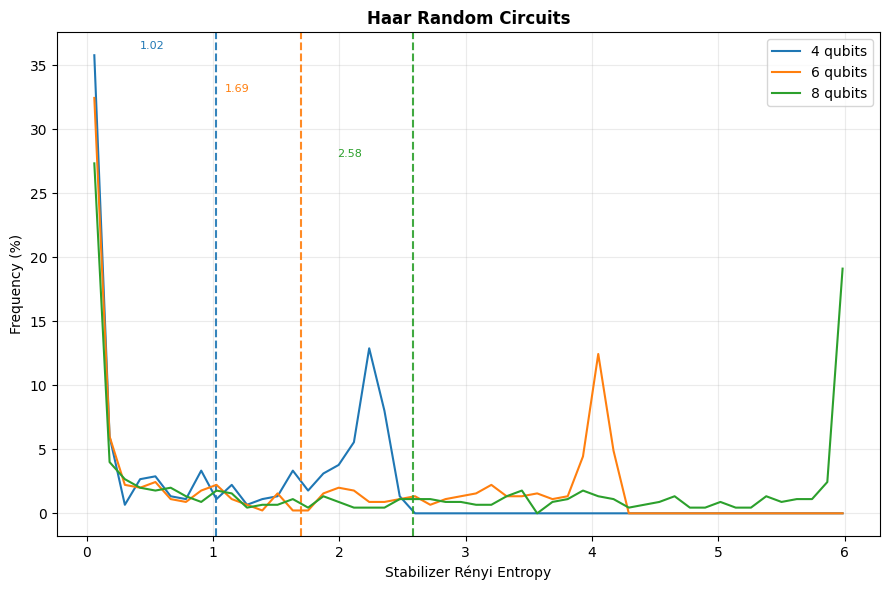

<Figure size 640x480 with 0 Axes>

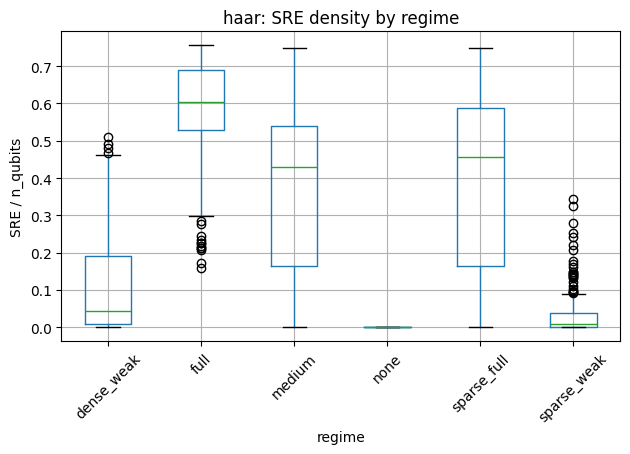

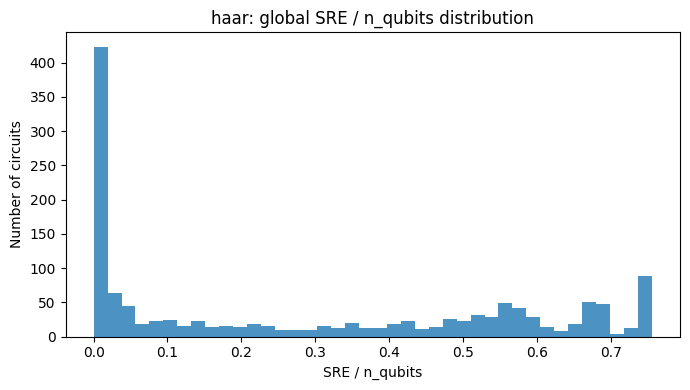

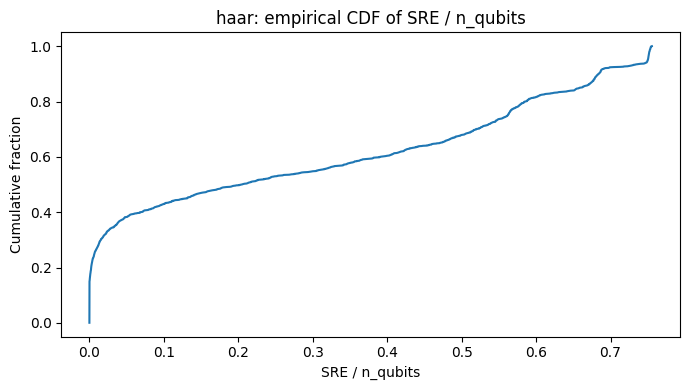

In [35]:
_plot_SRE_distribution(base_dataset_haar, bins=50, title="Haar Random Circuits")
plot_SRE_regime(output_dir, "haar")

plot_global_sre_distribution(df_qubits, "haar", density=True)
plot_sre_ecdf(df_qubits, "haar", density=True)

In [36]:
df_qubits = add_sre_bins(df_qubits)

coverage_table = pd.crosstab(
    df_qubits["family"],
    df_qubits["sre_bin"],
    normalize="index",
)

print(coverage_table)

sre_bin       zero      tiny  very_low       low  medium_low    medium  \
family                                                                   
clifford  0.316296  0.000000  0.146667  0.182963    0.118519  0.066667   
haar      0.147407  0.234815  0.046667  0.068148    0.080741  0.100741   
random    0.035556  0.339259  0.073333  0.112593    0.108889  0.084444   

sre_bin       high  very_high  
family                         
clifford  0.155556   0.013333  
haar      0.270370   0.051111  
random    0.232593   0.013333  
